Connectivity matrix:

[[ 1.    0.51  0.1  -0.01 -0.09]
 [ 0.51  1.    0.1  -0.   -0.03]
 [ 0.1   0.1   1.    0.03  0.13]
 [-0.01 -0.    0.03  1.   -0.04]
 [-0.09 -0.03  0.13 -0.04  1.  ]]


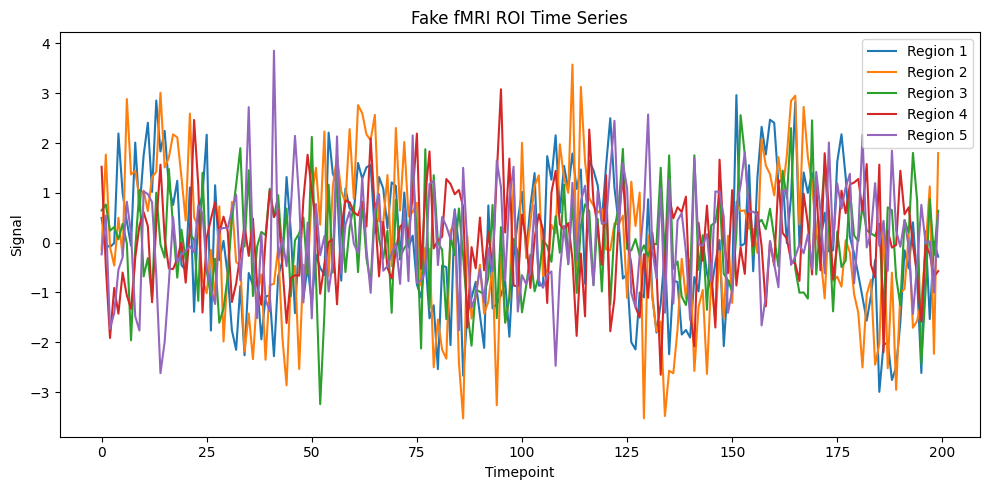

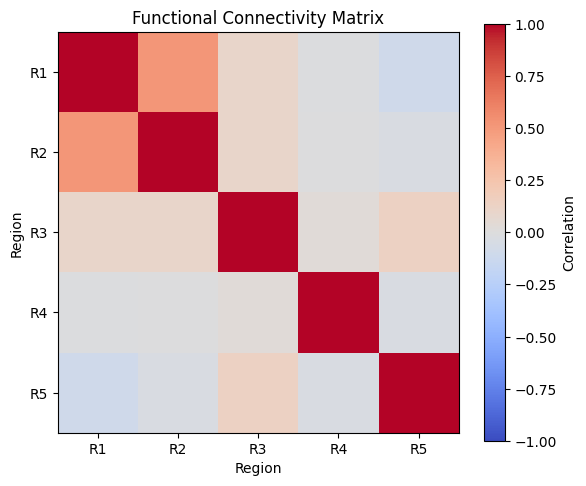

In [1]:
# simple_fmri_network_demo.py
# A tiny demonstration of the logic behind fMRI network analysis
# This is NOT a full real fMRI pipeline.
# It shows how brain-region time series can become a connectivity matrix.

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# STEP 1: Make fake fMRI time-series data
# ----------------------------
# Imagine these are signals from 5 brain regions measured across time.
# In real fMRI, each region would come from averaging many voxels over many scans.

np.random.seed(42)   # makes results reproducible

n_timepoints = 200   # number of fMRI time samples
n_regions = 5        # number of brain regions

# Start with random noise for all regions
data = np.random.randn(n_timepoints, n_regions)

# ----------------------------
# STEP 2: Add a shared signal to two regions
# ----------------------------
# This makes Region 1 and Region 2 "functionally connected"
# because they rise and fall together more than the others.

shared_signal = np.sin(np.linspace(0, 8 * np.pi, n_timepoints))

data[:, 0] += shared_signal * 1.5   # region 1
data[:, 1] += shared_signal * 1.5   # region 2

# ----------------------------
# STEP 3: Compute the connectivity matrix
# ----------------------------
# Correlation is the simplest functional connectivity measure.
# The result is a square matrix: region-by-region correlation.

connectivity_matrix = np.corrcoef(data.T)

# ----------------------------
# STEP 4: Print the matrix
# ----------------------------
print("Connectivity matrix:\n")
print(np.round(connectivity_matrix, 2))

# ----------------------------
# STEP 5: Plot the region time series
# ----------------------------
# This helps you see that Region 1 and Region 2 move together.

plt.figure(figsize=(10, 5))
for i in range(n_regions):
    plt.plot(data[:, i], label=f"Region {i+1}")
plt.title("Fake fMRI ROI Time Series")
plt.xlabel("Timepoint")
plt.ylabel("Signal")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# STEP 6: Plot the connectivity matrix
# ----------------------------
# This is the "brain network" view in matrix form.

plt.figure(figsize=(6, 5))
plt.imshow(connectivity_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Functional Connectivity Matrix")
plt.xlabel("Region")
plt.ylabel("Region")
plt.xticks(range(n_regions), [f"R{i+1}" for i in range(n_regions)])
plt.yticks(range(n_regions), [f"R{i+1}" for i in range(n_regions)])
plt.tight_layout()
plt.show()

## The smallest useful Python demo

This code does not download a big real dataset yet.

It does something better for learning:

creates fake ROI time series

makes one pair strongly connected

computes a connectivity matrix

plots the matrix

This lets you understand the logic of the network step.

## What this code teaches you

This is the key idea:

each brain region has a signal over time

if two regions move together, correlation is high

all pairwise correlations form a matrix

that matrix is one simple description of a brain network

So if a PI asks what functional connectivity is, you can say:

“It is usually a measure of how similarly activity in two brain regions changes over time, often using correlation.”